# 01 - Data

Runs once, on CPU.

What happens here: load the raw file, look at it (how many rows, how many per intent, how long the texts are), clean it, split it into train / val / test, and save the result into `data/processed/`.

Once this notebook has run, the split is frozen and is never touched again. Everything after this only reads it.

---

**The division of labour in this project.** Every function lives in `src/data.py` and takes a table and returns a table - no printing, no plots. This notebook calls those functions, prints, plots and writes files.

That is not a style preference. A notebook invites small edits: you nudge a threshold from 0.90 to 0.88 "just to see", and at that moment the split silently changes. A training run from two hours ago and a run from now were then trained on different data, and the comparison between them is meaningless with no warning anywhere. Freezing the logic into a module and the result into files on disk is what turns the experiment table into a measurement.

**What is on disk when this notebook finishes**

```
data/processed/clean/{train,val,test}.csv     <- the real split
data/processed/naive/{train,val,test}.csv     <- the control group
data/processed/split_manifest.json            <- the identity card (this one is committed)
artifacts/{labels,intent2cat,urgency_prior}.json
results/figures/*.png                          <- four figures
```

## 0 - Bootstrap

Two jobs: make `src/` importable from the notebook, and record the environment.

The versions matter more than they look. `train_test_split` is not guaranteed to produce identical splits across major scikit-learn versions, and `transformers < 4.51` does not know the `qwen3` architecture at all (it raises `KeyError: 'qwen3'`, which does not point at the real cause). Both numbers go into the manifest, so that a split that cannot be reproduced can at least be explained.

In [1]:
import sys, json, platform
from pathlib import Path

# Works both locally and in Colab: find the repo root, then put it on sys.path
# so that `import src.data` resolves the same way in both places.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import sklearn, scipy
import matplotlib
import matplotlib.pyplot as plt

import src.data as D

LIBRARY_VERSIONS = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "scipy": scipy.__version__,
}
print("repo root :", REPO_ROOT)
for k, v in LIBRARY_VERSIONS.items():
    print(f"{k:>13} : {v}")
print("\nsplit seed:", D.SPLIT_SEED, "| near-duplicate threshold:", D.NEAR_DUP_THRESHOLD)

repo root : c:\Users\emmav\Desktop\לימודים\תרגילים\פרויקט 3\support-triage
       python : 3.13.14
       pandas : 3.0.3
        numpy : 2.5.1
 scikit-learn : 1.9.0
        scipy : 1.18.0

split seed: 42 | near-duplicate threshold: 0.9


## 1.1 - Load the file and verify it by hand

Three numbers, checked before anything else: **26,872 rows / 27 intents / 11 categories**.

If any of them has moved, the file upstream was updated and every number in the report would silently describe a different dataset. `verify_raw` therefore raises rather than warns - a warning scrolls past in a notebook.

In [2]:
raw_path = REPO_ROOT / "data" / "raw" / D.RAW_FILENAME
df_raw = D.load_raw(REPO_ROOT / "data" / "raw")
df_raw = df_raw.reset_index(names="row_id")   # keep a stable pointer back to the raw file

print("verified:", D.verify_raw(df_raw))
print("sha256 of the raw file:", D.sha256_of_file(raw_path)[:16], "...")
print("\nshape:", df_raw.shape)
df_raw.head(3)

verified: {'n_rows': 26872, 'n_intents': 27, 'n_categories': 11}
sha256 of the raw file: 6f81102b0100b97b ...

shape: (26872, 6)


,row_id,flags,instruction,category,intent,response
0,0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


### What each column is for, and the two traps

| column | what is in it | its role |
|---|---|---|
| `instruction` | the customer message, up to ~92 characters | **the only model input. Full stop.** |
| `intent` | 27 values | the label - what the model predicts |
| `category` | 11 values | not trained. Derived from the intent through a lookup table |
| `flags` | letters marking which linguistic variation was applied to the row | **forbidden as a feature.** Excellent for error analysis |
| `response` | the templated answer | untouched in stage 1. Raw material for stage 2 (RAG) |

**Trap 1 - `response` reaching the features.** Writing `X = df.drop(columns=["intent"])` puts the answer inside the input; the model reads the reply and reports an F1 near 0.999. This is why `response` is not even written into the split CSVs: the mistake is made impossible rather than merely discouraged.

**Trap 2 - `flags` as a feature.** It is real information, but it is metadata about how the dataset was *generated*. A real incoming ticket does not carry it. A model that leans on it works beautifully in a notebook and cannot be deployed at all. The name for this is **train/serving skew**, and the same principle bans lowercasing and stopword removal further down.

In [3]:
# The one-line version of trap 1, so the size difference is visible:
print("mean length of `instruction`:", int(df_raw["instruction"].str.len().mean()), "chars")
print("mean length of `response`   :", int(df_raw["response"].str.len().mean()), "chars")
print("\nrows per intent - min:", df_raw["intent"].value_counts().min(),
      "max:", df_raw["intent"].value_counts().max())
print("\nthe input is defined explicitly, never by subtraction:")
print("    X = df['instruction']      y = df['intent']")

mean length of `instruction`: 46 chars
mean length of `response`   : 634 chars

rows per intent - min: 950 max: 1000

the input is defined explicitly, never by subtraction:
    X = df['instruction']      y = df['intent']


### The flags column - and a discrepancy worth reporting

The dataset card documents **12** generation tags: `M L B I C N P Q W K E Z`. The file contains **14** distinct letters. Two of them - `S` and `V` - are documented nowhere, neither in the "in use" list nor in the "not in use" list.

This is the second place where the published documentation disagrees with the actual file (the first is the category list, below). It costs nothing to count them yourself, and "we verified the tag inventory against the file rather than the card" is a sentence worth having in the report.

In [4]:
from collections import Counter

flag_counts = Counter("".join(df_raw["flags"].astype(str)))
documented = set("MLBICNPQWKEZ")
tbl = pd.DataFrame(
    [{"flag": f, "rows": n, "pct_of_dataset": round(100 * n / len(df_raw), 2),
      "documented": f in documented} for f, n in flag_counts.most_common()])
display(tbl)

for f in sorted(set(flag_counts) - documented):
    sub = df_raw[df_raw["flags"].str.contains(f, regex=False)]
    print(f"\nundocumented flag '{f}': {len(sub)} rows, intents = {sorted(sub['intent'].unique())}")
    print("   example:", sub["instruction"].iloc[0])

,flag,rows,pct_of_dataset,documented
0,B,26872,100.00,True
1,L,24115,89.74,True
2,Q,8968,33.37,True
3,I,7839,29.17,True
4,Z,5286,19.67,True
5,M,4920,18.31,True
6,C,2646,9.85,True
7,K,2227,8.29,True
8,E,1882,7.00,True
9,P,1329,4.95,True



undocumented flag 'S': 417 rows, intents = ['delivery_options']
   example: do you ship to {{Delivery City}}?

undocumented flag 'V': 77 rows, intents = ['cancel_order', 'check_invoice', 'get_refund', 'recover_password']
   example: I cannot pay for the last purchase I have made, cancel it


### The category list in the file vs the published documentation

The dataset card claims *"27 intents assigned to 10 categories"* and lists 21 intents under 10 headings. The file has 27 intents under 11 categories, and three of the category names in our own notes were wrong too (`SHIPPING_ADDRESS`, `CANCELLATION_FEE`, `NEWSLETTER` are really `SHIPPING`, `CANCEL`, `SUBSCRIPTION`).

This is exactly why `intent2cat.json` is **built from the DataFrame and never typed in from documentation**.

In [5]:
mapping_check = df_raw.groupby("intent")["category"].nunique()
print("intents mapping to more than one category:", int((mapping_check > 1).sum()), "(must be 0)")
print("\ncategories actually in the file:", sorted(df_raw['category'].unique()))
print("\nintents per category:")
print(df_raw.groupby("category")["intent"].nunique().sort_values(ascending=False).to_string())

intents mapping to more than one category: 0 (must be 0)

categories actually in the file: ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']

intents per category:
category
ACCOUNT         6
ORDER           4
REFUND          3
INVOICE         2
CONTACT         2
FEEDBACK        2
DELIVERY        2
SHIPPING        2
PAYMENT         2
CANCEL          1
SUBSCRIPTION    1


## 1.2 - The finding: measure the leakage *before* cleaning anything

### What "leakage" means here

This dataset was not collected from real customers. Linguists wrote a few dozen base templates, and an NLG engine expanded each one into dozens of variants: inflections, synonyms, question form instead of request, politeness, deliberate typos. So many rows are **siblings of one template**, not independent examples.

In an ordinary random split those siblings scatter across train and test. The model is then evaluated on sentences it has already seen almost word for word, gets an inflated score, and looks like it generalised. It did not.

So: split naively first - exactly the way everyone does it - and then ask how much of it leaked. Three numbers, twenty minutes, and they turn into a sentence a reader can verify from the code.

**How similarity is measured.** TF-IDF over character n-grams (3-5) inside word boundaries, cosine similarity. Character level and not word level because the data contains deliberate typos: "delivery" and "deliverly" share almost every 3-gram and not a single word. One single vector space is fitted here and reused for clustering and for both verification passes - otherwise "cleaned above 0.90" and "0.9 similar" would be numbers in different units.

In [6]:
# Whitespace normalisation first: a double space is a typing artefact, and
# without collapsing it two identical sentences look different to every
# comparison that follows.
df_ws = D.drop_empty_rows(D.normalise_whitespace(df_raw))
print(f"rows after whitespace normalisation / empty-row removal: {len(df_ws)} (from {len(df_raw)})")

# A vector space over the data as it is now - BEFORE any de-duplication.
vec_before, X_before = D.build_vector_space(df_ws["instruction"])
print("vocabulary size:", len(vec_before.vocabulary_), "character n-grams")

pos_before = np.arange(len(df_ws))
df_ws = df_ws.assign(pos=pos_before)

rows after whitespace normalisation / empty-row removal: 26872 (from 26872)


vocabulary size: 10910 character n-grams


In [7]:
# The naive split: stratified 70/15/15, no clustering, no family awareness.
tr_b, va_b, te_b = D.split_stratified(df_ws, seed=D.SPLIT_SEED)
print(f"naive split on the un-deduplicated data: {len(tr_b)} / {len(va_b)} / {len(te_b)}")

sim_before = D.max_similarity_to_train(X_before, tr_b["pos"].values, te_b["pos"].values)
leak_before = D.leakage_summary(sim_before, D.exact_overlap(tr_b, te_b))

print("\n--- LEAKAGE IN A NAIVE SPLIT, BEFORE ANY CLEANING ---")
for k, v in leak_before.items():
    print(f"  {k:>24} : {v}")

naive split on the un-deduplicated data: 18810 / 4031 / 4031



--- LEAKAGE IN A NAIVE SPLIT, BEFORE ANY CLEANING ---
                 exact_pct : 10.49
               ge_0.95_pct : 30.64
               ge_0.90_pct : 52.02
               ge_0.80_pct : 82.71
     median_max_similarity : 0.906


Read that as one sentence for the report:

> In a plain random split, **X%** of the test rows appear verbatim in the training set and **Y%** sit within 0.10 cosine of a training row. At least that share of the reported score is not a measurement of generalisation.

### Label conflicts - the ceiling that cannot be crossed

Separate, cheap check: does the exact same sentence appear with two different intents? If so, no model can be right on both rows, and the theoretical maximum is below 100%.

Result here: **zero exact conflicts**. That is a clean negative finding and it should be reported as one - it means this particular ceiling argument does not apply to this dataset, and any claim that it does would be unfounded.

The softer version of the same question does bite, though: *near*-identical sentences carrying different labels. Those are not duplicates to remove - they are genuine semantic conflicts, and they are the qualitative evidence for why 100% is unreachable. We deliberately keep them, and collect a few examples for the report.

In [8]:
conflicts = D.find_label_conflicts(df_ws)
print("rows involved in an exact label conflict:", len(conflicts))
print("distinct conflicting sentences        :", conflicts['instruction'].nunique())

rows involved in an exact label conflict: 0
distinct conflicting sentences        : 0


In [9]:
# The soft version: for a sample of rows, find the nearest neighbour that
# carries a DIFFERENT intent, and keep the pairs above 0.90.
rng = np.random.default_rng(D.SPLIT_SEED)
sample_pos = rng.choice(len(df_ws), size=3000, replace=False)
intents_all = df_ws["intent"].values
examples = []

for start in range(0, len(sample_pos), 500):
    idx = sample_pos[start:start + 500]
    S = (X_before[idx] @ X_before.T).toarray()
    for j, i in enumerate(idx):
        S[j, i] = 0.0                                   # ignore the row itself
        S[j][intents_all == intents_all[i]] = 0.0       # keep only cross-intent neighbours
        k = int(S[j].argmax())
        if S[j, k] >= 0.90:
            examples.append((round(float(S[j, k]), 3), intents_all[i], df_ws['instruction'].iloc[i],
                             intents_all[k], df_ws['instruction'].iloc[k]))

examples = sorted(set(examples), reverse=True)
print(f"cross-intent near-duplicate pairs found in a 3,000-row sample: {len(examples)}")
print(f"that is {100*len(examples)/3000:.2f}% of the sampled rows\n")
for sim, i1, t1, i2, t2 in examples[:5]:
    print(f"  sim={sim}\n    [{i1}] {t1}\n    [{i2}] {t2}")

cross-intent near-duplicate pairs found in a 3,000-row sample: 37
that is 1.23% of the sampled rows

  sim=0.96
    [create_account] creating user
    [registration_problems] help creating user
  sim=0.939
    [get_invoice] what do I need to do to get my bill from {{Person Name}}?
    [check_invoice] what do I need to do to see my bill from {{Person Name}}?
  sim=0.939
    [get_invoice] get invoices from December
    [check_invoice] check invoices from December
  sim=0.936
    [get_refund] refund {{Currency Symbol}}{{Refund Amount}}
    [track_refund] I expect a refund of {{Currency Symbol}}{{Refund Amount}}
  sim=0.934
    [track_refund] i expect a rebate of {{Currency Symbol}}{{Refund Amount}}
    [get_refund] rebate {{Currency Symbol}}{{Refund Amount}}


## 1.3 - Cleaning

### Text cleaning: much less than a classic NLP course would tell you

**What we do:** collapse repeated whitespace, drop empty rows, keep UTF-8. That is all.

**What we deliberately do not do** - lowercasing, punctuation stripping, stopword removal, stemming - and the three reasons, because they are exam questions:

1. The model was pre-trained on raw text. Every normalisation step moves the input further from the distribution it was trained on.
2. A question mark is a signal for query-type intents. Punctuation here is a feature, not noise.
3. Function words are precisely what separates `get_invoice` from `check_invoice`. Removing stopwords deletes the only information there is.

And above all: **whatever is not done at serving time must not be done at training time.** Same train/serving skew, from the other direction.

In [10]:
# Exact duplicates - and the trap that makes this line look like it worked
# when it did nothing at all.
no_subset = len(df_ws.drop_duplicates())                 # compares EVERY column
with_subset = len(D.drop_exact_duplicates(df_ws))        # compares instruction + intent

print(f"rows now                              : {len(df_ws)}")
print(f"drop_duplicates()      -> removes     : {len(df_ws) - no_subset} rows   <- the trap")
print(f"subset=[instruction,intent] -> removes: {len(df_ws) - with_subset} rows   <- correct")
print("\nWhy: the default also compares `flags` and `response`. Two rows with the")
print("same text but different flag strings are 'different' rows, so nothing is removed.")

rows now                              : 26872
drop_duplicates()      -> removes     : 0 rows   <- the trap
subset=[instruction,intent] -> removes: 2318 rows   <- correct

Why: the default also compares `flags` and `response`. Two rows with the
same text but different flag strings are 'different' rows, so nothing is removed.


In [11]:
df_dedup = D.drop_exact_duplicates(df_ws).reset_index(drop=True)
df_dedup["pos"] = np.arange(len(df_dedup))
print(f"{len(df_raw)} raw -> {len(df_dedup)} after exact de-duplication "
      f"({100*len(df_dedup)/len(df_raw):.1f}% kept)")

26872 raw -> 24554 after exact de-duplication (91.4% kept)


### Near-duplicates: cluster them, do not delete them

The most interesting technical step of the day. The idea: give every row a **family number**, so that all rows born from the same template share one number. Then, when we split, a whole family lands on one side.

Three properties this implementation depends on:

1. **Blocked by intent.** All-pairs over 26,872 rows is 722M cells (~2.9 GB in float32) and would exhaust a CPU Colab. A near-duplicate always sits inside one intent, because it came from the same template - so we run 27 blocks of ~900 rows instead. Seconds.
2. **Character n-grams, not words.** Because of the deliberate typos and morphological variants.
3. **Connected components, not pairwise deletion.** If A~B and B~C but A and C are not similar to each other, all three are still one family. Delete in pairs and A and C survive on opposite sides of the split: cleaned, and still leaking.

One fitted vector space is reused from the section above (refitted here on the de-duplicated frame, which is the corpus that actually gets split).

In [12]:
vec, X = D.build_vector_space(df_dedup["instruction"])
print("vector space:", X.shape[0], "rows x", X.shape[1], "character n-grams,",
      f"{X.nnz:,} non-zeros ({100*X.nnz/(X.shape[0]*X.shape[1]):.2f}% dense)")

vector space: 24554 rows x 10579 character n-grams, 2,183,015 non-zeros (0.84% dense)


### The threshold is a choice, not a fact - so measure the sensitivity

0.90 is a number somebody picked. The cheap justification is to count how many families survive at 0.80 / 0.85 / 0.90 / 0.95. A flat curve around 0.90 means the choice is stable; a steep one is a sensitivity that has to be reported.

**Here the curve is steep** - 18.7% / 35.1% / 57.6% / 81.0% of rows survive as families. So the honest report sentence is not "0.90 is stable" but "the threshold is a real knob, and here is what each setting costs". The second table below is the one that actually decides it: for each threshold, how much *residual* leakage is left in the resulting clean split, against how much data it costs.

**An honest caveat about that second table**, because it is the kind of thing an examiner should catch: the residual-similarity column is partly tautological. Clustering at threshold *t* removes same-intent pairs above *t* by construction, so of course a split cleaned at 0.90 has almost nothing left above 0.90. What the column actually shows is the **failure** case - at 0.95 the cleaning leaves 30% of test rows within 0.10 of a training row - and where the cliff sits. The informative trade-off is between that column and `train_rows_per_intent`: 0.85 and 0.80 are equally clean and cost 40% and 68% of the training data respectively, for no measurable gain.

In [13]:
scan = D.threshold_scan(X, df_dedup["intent"].values)
display(scan)

,threshold,n_groups,retained_pct,mean_family_size
0,0.80,4582,18.7,5.36
1,0.85,8608,35.1,2.85
2,0.90,14133,57.6,1.74
3,0.95,19879,81.0,1.24


In [14]:
# For each candidate threshold: build the clean split it would produce and
# measure how much test<->train similarity survives. This is the number that
# matters - the family count alone does not tell you whether it worked.
rows = []
for t in [0.80, 0.85, 0.90, 0.95]:
    g = D.near_duplicate_groups(X, df_dedup["intent"].values, threshold=t)
    reps = D.pick_representatives(df_dedup.assign(dup_group=g))
    tr, va, te = D.split_stratified(reps, seed=D.SPLIT_SEED)
    s = D.max_similarity_to_train(X, tr["pos"].values, te["pos"].values)
    rows.append({"threshold": t, "rows_kept": len(reps), "train_rows": len(tr),
                 "train_rows_per_intent": round(len(tr) / 27),
                 "test>=0.95_pct": round(100 * float((s >= 0.95).mean()), 2),
                 "test>=0.90_pct": round(100 * float((s >= 0.90).mean()), 2),
                 "median_max_sim": round(float(np.median(s)), 3)})
threshold_tradeoff = pd.DataFrame(rows)
display(threshold_tradeoff)
print("Chosen: 0.90 - the loosest threshold at which residual test<->train similarity")
print("above 0.90 is essentially zero, while still leaving ~350 training rows per intent.")

,threshold,rows_kept,train_rows,train_rows_per_intent,test>=0.95_pct,test>=0.90_pct,median_max_sim
0,0.80,4582,3207,119,0.00,0.15,0.655
1,0.85,8608,6025,223,0.00,0.46,0.740
2,0.90,14133,9893,366,0.05,0.24,0.809
3,0.95,19879,13915,515,0.00,30.32,0.865


Chosen: 0.90 - the loosest threshold at which residual test<->train similarity
above 0.90 is essentially zero, while still leaving ~350 training rows per intent.


In [15]:
groups = D.near_duplicate_groups(X, df_dedup["intent"].values, threshold=D.NEAR_DUP_THRESHOLD)
df_dedup["dup_group"] = groups
n_groups = df_dedup["dup_group"].nunique()
sizes = df_dedup["dup_group"].value_counts()

print(f"families at threshold {D.NEAR_DUP_THRESHOLD}: {n_groups:,} "
      f"({100*n_groups/len(df_dedup):.1f}% of {len(df_dedup):,} rows)")
print(f"family sizes - mean {sizes.mean():.2f}, median {int(sizes.median())}, max {sizes.max()}")
print("\nfamily size distribution:")
print(sizes.value_counts().sort_index().head(8).to_string())

families at threshold 0.9: 14,133 (57.6% of 24,554 rows)
family sizes - mean 1.74, median 1, max 117

family size distribution:
count
1    11100
2     1498
3      546
4      285
5      167
6      137
7       76
8       71


In [16]:
# What a family actually looks like - this is the whole argument in one screenshot.
biggest = sizes.index[0]
fam = df_dedup[df_dedup["dup_group"] == biggest]
print(f"family #{biggest} - intent '{fam['intent'].iloc[0]}', {len(fam)} rows:\n")
for t, f in zip(fam["instruction"].head(10), fam["flags"].head(10)):
    print(f"  [{f:<8}] {t}")

family #8619 - intent 'newsletter_subscription', 117 rows:

  [BLZ     ] I try tro subscribe to the newsletter
  [BL      ] I can't unsubscribe from your company newsletter
  [BL      ] I am trying to unsubscribe from your company newsletter
  [BL      ] I try to unsubscribe to your company newsletter
  [BL      ] assistance to unsubscribe from the company newsletter
  [BLP     ] I don't know how I could unsubscribe to the newsletter
  [BL      ] I want help to unsubscribe to the company newsletter
  [BLQ     ] i need help to unsubscribe from ur company newsletter
  [BL      ] I have got to unsubscribe to the newsletter
  [BIL     ] can you help me unsubscribe to the newsletter?


### Which row represents the family?

One row per family survives. **Which** one looked like it might matter: the file is ordered by construction, so if the first member of each family were the plain base variant and the typo / keyword-only variants came after it, always taking the first would build a "clean" set of tidy grammatical sentences and quietly strip out exactly the noisy rows the robustness analysis in stage 5 needs.

The representative is therefore drawn at random with the frozen split seed. The table below tested that worry - **and it did not hold**: random selection and first-row selection produce nearly the same flag mix (28.0% vs 28.0% typos). The concern was reasonable and the measurement says it costs nothing either way; random selection is kept because it is the principled default, not because it was shown to help.

**What the same table did reveal** is a real distribution shift, and it belongs in the report: the clean set carries *more* typos than the raw data (19.3% -> 28.0%), not fewer. The reason is mechanical - a heavily mangled sentence is less similar to its siblings, so it more often forms a family of its own and survives as its own representative, while thirty polite paraphrases of one template collapse into a single row. **Family-aware cleaning does not just shrink the dataset; it makes it harder.** Any drop in score from naive to clean is therefore partly leakage and partly a genuinely more difficult test set, and the report should say so rather than attribute all of it to leakage.

In [17]:
reps_random = D.pick_representatives(df_dedup, seed=D.SPLIT_SEED)
reps_first  = df_dedup.drop_duplicates(subset="dup_group")     # naive alternative

def flag_share(frame):
    c = Counter("".join(frame["flags"].astype(str)))
    return {f: round(100 * c[f] / len(frame), 1) for f in "ZKQWP"}

comparison = pd.DataFrame({
    "all rows (before clustering)": flag_share(df_dedup),
    "representative = random (used)": flag_share(reps_random),
    "representative = first (rejected)": flag_share(reps_first),
})
comparison.index.name = "flag (% of rows carrying it)"
display(comparison)
print("Z = typos, K = keyword-only, Q = colloquial, W = offensive, P = polite.\n")
print("Read the two right-hand columns against each other: the choice of representative")
print("barely matters. Read either of them against the left column: cleaning shifts the")
print("distribution - a mangled sentence is less similar to its siblings, so it survives")
print("as its own family, while 30 polite paraphrases collapse into one row.")

,all rows (before clustering),representative = random (used),representative = first (rejected)
flag (% of rows carrying it),,,
Z,19.3,28.0,28.0
K,6.0,7.1,7.1
Q,34.3,34.9,35.1
W,5.2,7.9,7.9
P,5.3,7.3,7.4


Z = typos, K = keyword-only, Q = colloquial, W = offensive, P = polite.

Read the two right-hand columns against each other: the choice of representative
barely matters. Read either of them against the left column: cleaning shifts the
distribution - a mangled sentence is less similar to its siblings, so it survives
as its own family, while 30 polite paraphrases collapse into one row.


### The before/after table

Four rows, the one the guide asks for. Plus per-intent retention, because an aggregate number can hide one intent collapsing to nothing.

In [18]:
before_after = pd.DataFrame([
    {"stage": "raw file",                       "rows": len(df_raw)},
    {"stage": "after whitespace + empty rows",  "rows": len(df_ws)},
    {"stage": "after exact duplicates",         "rows": len(df_dedup)},
    {"stage": f"after family clustering @ {D.NEAR_DUP_THRESHOLD}", "rows": len(reps_random)},
])
before_after["pct_of_raw"] = (100 * before_after["rows"] / len(df_raw)).round(1)
display(before_after)

retention = (100 * reps_random["intent"].value_counts() /
             df_raw["intent"].value_counts()).round(1).sort_values()
print("per-intent retention %, lowest and highest five:")
print(pd.concat([retention.head(5), retention.tail(5)]).to_string())

,stage,rows,pct_of_raw
0,raw file,26872,100.0
1,after whitespace + empty rows,26872,100.0
2,after exact duplicates,24554,91.4
3,after family clustering @ 0.9,14133,52.6


per-intent retention %, lowest and highest five:
intent
cancel_order               20.1
track_order                26.0
newsletter_subscription    33.3
track_refund               35.7
get_invoice                36.7
edit_account               67.0
change_shipping_address    69.7
review                     74.4
recover_password           79.7
place_order                81.9


## 1.4 - Split, twice, and freeze

| set | share | when it is touched |
|---|---|---|
| train | 70% | constantly - the model learns from it |
| val | 15% | every check during tuning, as often as we like |
| test | 15% | **once**, at the very end |

`train_test_split` has no three-way mode, so it runs twice: 70/30, then the 30 cut in half.

**Stratify on `intent` (27), not on `category` (11).** Stratifying on categories does not guarantee that every one of the 27 intents appears in val; a missing intent makes macro-F1 average 26 classes instead of 27, and nothing complains.

**Two seeds that are both called "seed".** The split seed (42) is frozen here forever. The *training* seed is a different constant, in a different file, and it is the one that varies across the three noise-floor runs. Confusing them produces variance that looks like training noise and is really different data.

### Two full splits

- `clean/` respects the families - **this is the real split**, everything is built on it.
- `naive/` is the ordinary random split with no clustering - **the control group**, which is what later proves how much the leakage inflated the score.

`naive/` is built from the same exactly-de-duplicated frame. Exact-duplicate removal is uncontroversial and everybody does it; the variable under test is family awareness, and only that.

In [19]:
clean_tr, clean_va, clean_te = D.split_stratified(reps_random, seed=D.SPLIT_SEED)
naive_tr, naive_va, naive_te = D.split_stratified(df_dedup,   seed=D.SPLIT_SEED)

print(f"clean : {len(clean_tr)} / {len(clean_va)} / {len(clean_te)}   (total {len(reps_random)})")
print(f"naive : {len(naive_tr)} / {len(naive_va)} / {len(naive_te)}   (total {len(df_dedup)})")

# The check that stratification actually did its job: all 27 intents present
# in every one of the six files.
for name, part in [("clean/train", clean_tr), ("clean/val", clean_va), ("clean/test", clean_te),
                   ("naive/train", naive_tr), ("naive/val", naive_va), ("naive/test", naive_te)]:
    assert part["intent"].nunique() == 27, f"{name} is missing an intent!"
print("\nall six splits contain all 27 intents.")
print(f"smallest intent in clean/val: {clean_va['intent'].value_counts().min()} rows")

clean : 9893 / 2120 / 2120   (total 14133)
naive : 17187 / 3683 / 3684   (total 24554)

all six splits contain all 27 intents.
smallest intent in clean/val: 30 rows


### Verify that the clean split is actually clean

The claim is "no test row sits within 0.10 cosine of a training row". It is only worth making if it is measured, in the same vector space that was used to do the cleaning.

The residual that survives is the interesting part: it is **cross-intent** similarity - near-identical sentences carrying different labels. That is not leakage, it is the semantic-conflict phenomenon from above, and removing it would destroy exactly the hard cases the model should be judged on.

In [20]:
sim_clean = D.max_similarity_to_train(X, clean_tr["pos"].values, clean_te["pos"].values)
sim_naive = D.max_similarity_to_train(X, naive_tr["pos"].values, naive_te["pos"].values)

leak_clean = D.leakage_summary(sim_clean, D.exact_overlap(clean_tr, clean_te))
leak_naive = D.leakage_summary(sim_naive, D.exact_overlap(naive_tr, naive_te))

leak_table = pd.DataFrame({
    "naive (before cleaning, incl. exact dups)": leak_before,
    "naive (committed control split)": leak_naive,
    "clean (committed real split)": leak_clean,
}).T
display(leak_table)

,exact_pct,ge_0.95_pct,ge_0.90_pct,ge_0.80_pct,median_max_similarity
"naive (before cleaning, incl. exact dups)",10.49,30.64,52.02,82.71,0.906
naive (committed control split),0.00,23.97,47.29,80.75,0.894
clean (committed real split),0.00,0.05,0.24,55.05,0.809


In [21]:
# Is the residual same-intent (real leakage) or cross-intent (a hard case)?
A = X[clean_tr["pos"].values]
B = X[clean_te["pos"].values]
tr_int, te_int = clean_tr["intent"].values, clean_te["intent"].values
same_intent_max = np.zeros(len(te_int), dtype=np.float32)
nn_intent = np.empty(len(te_int), dtype=object)

for s in range(0, B.shape[0], 500):
    block = (B[s:s + 500] @ A.T).toarray()
    for j in range(block.shape[0]):
        same_intent_max[s + j] = block[j][tr_int == te_int[s + j]].max()
        nn_intent[s + j] = tr_int[int(block[j].argmax())]

above = sim_clean >= 0.90
print(f"clean/test rows with any train neighbour >= 0.90 : {above.sum()} ({100*above.mean():.2f}%)")
print(f"   of those, nearest neighbour is a DIFFERENT intent: {(above & (nn_intent != te_int)).sum()}")
print(f"clean/test rows with a SAME-intent neighbour >= 0.90: {(same_intent_max >= 0.90).sum()} "
      f"({100*(same_intent_max >= 0.90).mean():.2f}%)   <- this is the leakage number")

clean/test rows with any train neighbour >= 0.90 : 5 (0.24%)
   of those, nearest neighbour is a DIFFERENT intent: 5
clean/test rows with a SAME-intent neighbour >= 0.90: 0 (0.00%)   <- this is the leakage number


## 1.5 - Write the six CSVs, the manifest, and verify the round trip

`response` is not written. `flags` and `category` are, because error slicing and category-level metrics need them - but neither is ever a feature.

The manifest is the identity card: seed, threshold, row counts, a sha256 of the texts+labels of each split, the hash of the raw file and the library versions. The CSVs are gitignored and rebuilt from the seed; the manifest is what proves that a rebuild produced the same thing. Without it, an upstream dataset update or a scikit-learn major bump moves the split and nobody notices.

In [22]:
processed = REPO_ROOT / "data" / "processed"
splits = {
    "clean": {"train": clean_tr, "val": clean_va, "test": clean_te},
    "naive": {"train": naive_tr, "val": naive_va, "test": naive_te},
}

for name, parts in splits.items():
    (processed / name).mkdir(parents=True, exist_ok=True)
    for part, frame in parts.items():
        out = frame[D.SPLIT_COLUMNS]
        out.to_csv(processed / name / f"{part}.csv", index=False, encoding="utf-8")
        print(f"wrote {name}/{part}.csv  {len(out):>6} rows  {list(out.columns)}")

wrote clean/train.csv    9893 rows  ['row_id', 'instruction', 'intent', 'category', 'flags', 'dup_group']
wrote clean/val.csv    2120 rows  ['row_id', 'instruction', 'intent', 'category', 'flags', 'dup_group']
wrote clean/test.csv    2120 rows  ['row_id', 'instruction', 'intent', 'category', 'flags', 'dup_group']


wrote naive/train.csv   17187 rows  ['row_id', 'instruction', 'intent', 'category', 'flags', 'dup_group']
wrote naive/val.csv    3683 rows  ['row_id', 'instruction', 'intent', 'category', 'flags', 'dup_group']
wrote naive/test.csv    3684 rows  ['row_id', 'instruction', 'intent', 'category', 'flags', 'dup_group']


In [23]:
counts = {
    "raw": len(df_raw),
    "after_whitespace": len(df_ws),
    "after_exact_duplicates": len(df_dedup),
    "n_families": int(n_groups),
    "clean_total": len(reps_random),
}
manifest = D.build_manifest(raw_path, counts, splits,
                            library_versions=LIBRARY_VERSIONS)
manifest["leakage"] = {"naive_before_cleaning": leak_before,
                       "naive_committed": leak_naive,
                       "clean_committed": leak_clean}
D.write_json(manifest, processed / "split_manifest.json")
print(json.dumps(manifest, indent=2)[:1200], "\n...")

{
  "seed": 42,
  "near_dup_threshold": 0.9,
  "scheme": "70/15/15 stratified on intent, two-step",
  "source": {
    "hf_repo": "bitext/Bitext-customer-support-llm-chatbot-training-dataset",
    "filename": "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv",
    "sha256": "6f81102b0100b97b8468eb04368033a23206bf1fde9d53500d5806ec1001a434"
  },
  "tfidf_params": {
    "analyzer": "char_wb",
    "ngram_range": [
      3,
      5
    ],
    "min_df": 2,
    "sublinear_tf": true
  },
  "counts": {
    "raw": 26872,
    "after_whitespace": 26872,
    "after_exact_duplicates": 24554,
    "n_families": 14133,
    "clean_total": 14133
  },
  "splits": {
    "clean": {
      "train": {
        "n_rows": 9893,
        "sha256": "6d674bcb7d8fd254705cf847ebeefae9e3f9e356f385bb3c5b365819de78d177"
      },
      "val": {
        "n_rows": 2120,
        "sha256": "cee4cf6f0118f9a8fa35946fc91babebd25a6273108dfea1c473ada89c053d81"
      },
      "test": {
        "n_rows": 2120,
  

In [24]:
# The round trip: read the six files back off disk, re-hash them, and compare
# to the manifest. This is the assert the bootstrap cell of every other
# notebook will run - a reproducibility claim that checks itself.
reloaded = {
    name: {part: pd.read_csv(processed / name / f"{part}.csv")
           for part in ("train", "val", "test")}
    for name in ("clean", "naive")
}
D.verify_against_manifest(manifest, reloaded)
print("round trip OK - the files on disk match split_manifest.json exactly.")

round trip OK - the files on disk match split_manifest.json exactly.


## 1.6 - The three artifacts

Three small JSON files, created once, committed, and never moved. They are the contract every later stage leans on.

| file | contents | why it must stay stable |
|---|---|---|
| `labels.json` | the 27 intents, sorted | the model knows integers 0-26, not names. If the order shifts between runs, yesterday's checkpoint returns wrong answers with **no error** |
| `intent2cat.json` | intent -> category | built from the file, not the docs. Also stage 2's retrieval filter key |
| `urgency_prior.json` | 27 keys -> low/medium/high | a business rule (decision A2), written by hand once |

`labels.json` is the single deliberate exception to "fit on train only": class order is a contract, not a learned parameter, so it is built from all 27 labels on purpose.

In [25]:
artifacts = REPO_ROOT / "artifacts"
labels = D.build_labels(df_raw)
intent2cat = D.build_intent2cat(df_raw)
urgency = D.build_urgency_prior(labels)

assert len(labels) == 27 and labels == sorted(labels)
assert set(intent2cat) == set(labels) and len(set(intent2cat.values())) == 11
assert set(urgency) == set(labels) and set(urgency.values()) == {"low", "medium", "high"}

D.write_json(labels, artifacts / "labels.json")
D.write_json(intent2cat, artifacts / "intent2cat.json")
D.write_json(urgency, artifacts / "urgency_prior.json")

print("labels.json        :", labels[:3], "...", labels[-2:])
print("intent2cat.json    :", dict(list(intent2cat.items())[:3]), "...")
print("urgency_prior.json :", Counter(urgency.values()))

labels.json        : ['cancel_order', 'change_order', 'change_shipping_address'] ... ['track_order', 'track_refund']
intent2cat.json    : {'cancel_order': 'ORDER', 'change_order': 'ORDER', 'change_shipping_address': 'SHIPPING'} ...
urgency_prior.json : Counter({'medium': 11, 'high': 9, 'low': 7})


## 1.7 - Four figures. Not eight.

In a 2-3 page report every figure has to carry a claim. These four do:

1. **Class distribution before and after cleaning** - answers "describe the data", and the "after" is what later justifies reporting macro-F1.
2. **Text length in tokens** with the p99 line - this sets `max_length` for training, and training time grows roughly with the square of sequence length.
3. **Flag frequency** - the generation mechanism of the dataset in one picture, and the setup for error slicing in stage 5.
4. **test <-> train similarity, naive vs clean** - the strongest figure in the report.

Deliberately excluded: word clouds, a full 27x27 confusion matrix, a 27-row count table.

In [26]:
FIGDIR = REPO_ROOT / "results" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

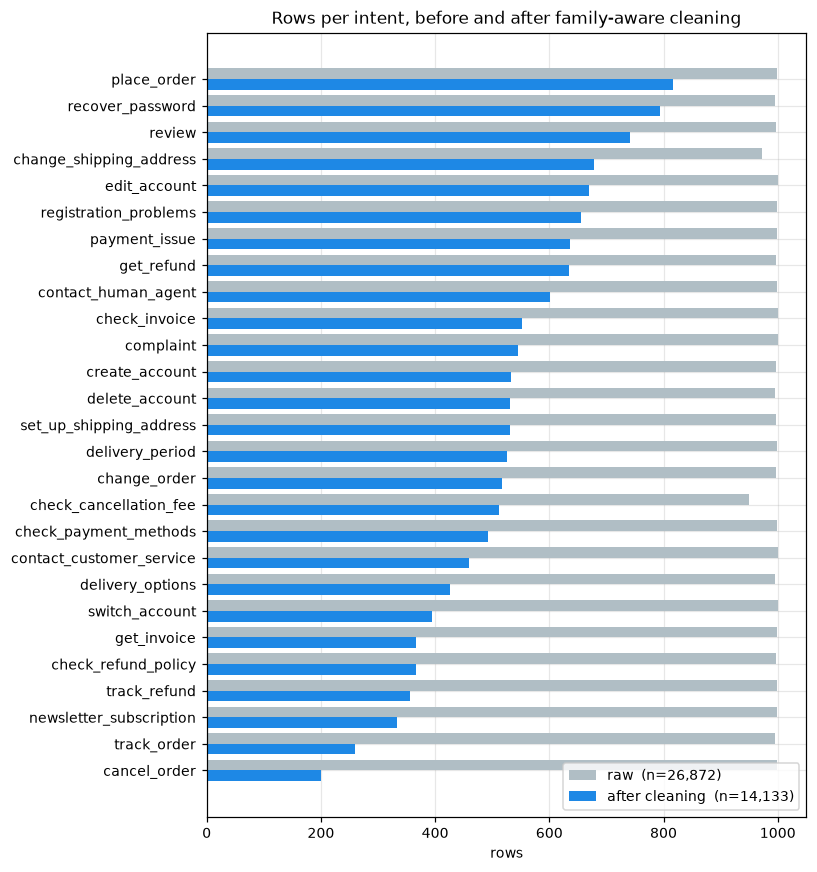

raw   : 950-1000 rows per intent (ratio 1.05)
clean : 201-817 rows per intent (ratio 4.06)

This is the claim the figure carries, and it is not the one we expected:
the raw dataset is balanced (1.05:1), the cleaned dataset is NOT (4.06:1).
Intents whose templates were expanded most aggressively - cancel_order keeps
20% of its rows, place_order keeps 82% - lose the most. So macro-F1 is not a
stylistic preference here: after cleaning, accuracy really can hide a small
class the model never gets right.


In [27]:
# Figure 1 - class distribution before and after cleaning
# Sorted by the AFTER count, not the before count: the raw distribution is flat,
# so sorting by it hides the whole point of the figure.
order = reps_random["intent"].value_counts().index[::-1]
before = df_raw["intent"].value_counts().reindex(order)
after = reps_random["intent"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(7.5, 8))
y = np.arange(len(order))
ax.barh(y + 0.2, before, height=0.4, label=f"raw  (n={len(df_raw):,})", color="#b0bec5")
ax.barh(y - 0.2, after,  height=0.4, label=f"after cleaning  (n={len(reps_random):,})", color="#1e88e5")
ax.set_yticks(y); ax.set_yticklabels(order); ax.set_xlabel("rows")
ax.set_title("Rows per intent, before and after family-aware cleaning")
ax.legend(loc="lower right"); fig.tight_layout()
fig.savefig(FIGDIR / "01_class_distribution.png", bbox_inches="tight"); plt.show()

print(f"raw   : {before.min()}-{before.max()} rows per intent (ratio {before.max()/before.min():.2f})")
print(f"clean : {after.min()}-{after.max()} rows per intent (ratio {after.max()/after.min():.2f})")
print("\nThis is the claim the figure carries, and it is not the one we expected:")
print("the raw dataset is balanced (1.05:1), the cleaned dataset is NOT (4.06:1).")
print("Intents whose templates were expanded most aggressively - cancel_order keeps")
print("20% of its rows, place_order keeps 82% - lose the most. So macro-F1 is not a")
print("stylistic preference here: after cleaning, accuracy really can hide a small")
print("class the model never gets right.")

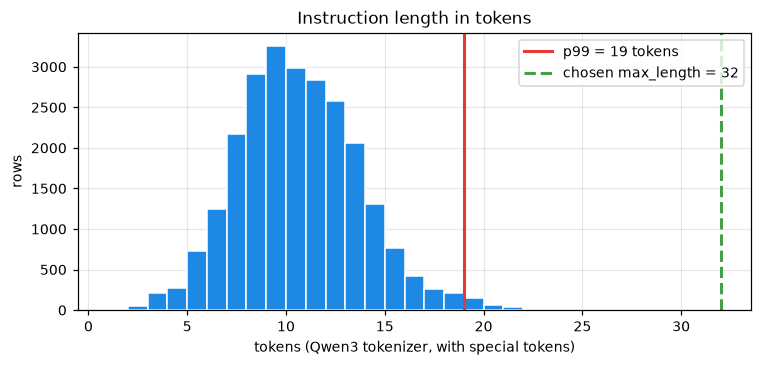

mean 10.2 | median 10 | p95 15 | p99 19 | max 24
rows truncated at max_length=32: 0 (0.000%)
the naive default of 512 would cost roughly (512/32)^2 = 256x the attention compute for the same result.


In [28]:
# Figure 2 - text length in TOKENS, with the p99 line that sets max_length
import os, warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore")

lengths = D.token_lengths(df_dedup["instruction"])
p99 = int(np.percentile(lengths, 99))
max_length = int(2 ** np.ceil(np.log2(p99)))

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(lengths, bins=range(1, lengths.max() + 2), color="#1e88e5", edgecolor="white")
ax.axvline(p99, color="#e53935", lw=2, label=f"p99 = {p99} tokens")
ax.axvline(max_length, color="#43a047", lw=2, ls="--", label=f"chosen max_length = {max_length}")
ax.set_xlabel("tokens (Qwen3 tokenizer, with special tokens)"); ax.set_ylabel("rows")
ax.set_title("Instruction length in tokens"); ax.legend(); fig.tight_layout()
fig.savefig(FIGDIR / "02_token_lengths.png", bbox_inches="tight"); plt.show()

print(f"mean {lengths.mean():.1f} | median {int(np.median(lengths))} | p95 {int(np.percentile(lengths,95))} "
      f"| p99 {p99} | max {lengths.max()}")
print(f"rows truncated at max_length={max_length}: {(lengths > max_length).sum()} "
      f"({100*(lengths > max_length).mean():.3f}%)")
print(f"the naive default of 512 would cost roughly (512/{max_length})^2 = "
      f"{(512/max_length)**2:.0f}x the attention compute for the same result.")

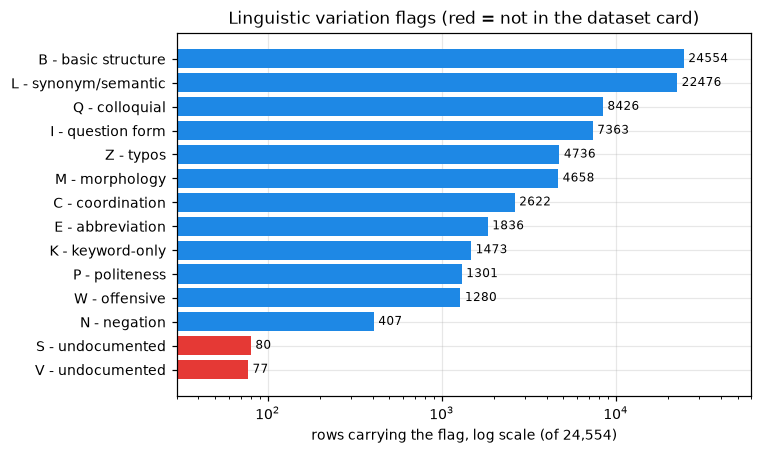

flags per row - mean: 3.31


In [29]:
# Figure 3 - flag frequency
counts_f = Counter("".join(df_dedup["flags"].astype(str)))
items = sorted(counts_f.items(), key=lambda kv: kv[1])
names = {"B": "basic structure", "L": "synonym/semantic", "Q": "colloquial", "I": "question form",
         "Z": "typos", "M": "morphology", "C": "coordination", "K": "keyword-only",
         "E": "abbreviation", "P": "politeness", "W": "offensive", "N": "negation",
         "S": "undocumented", "V": "undocumented"}

fig, ax = plt.subplots(figsize=(7, 4.2))
cols = ["#e53935" if f in ("S", "V") else "#1e88e5" for f, _ in items]
bars = ax.barh([f"{f} - {names.get(f,'?')}" for f, _ in items], [c for _, c in items], color=cols)
# Log scale, otherwise the two undocumented flags are invisible next to B and L.
ax.set_xscale("log"); ax.set_xlim(30, 60000)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel(f"rows carrying the flag, log scale (of {len(df_dedup):,})")
ax.set_title("Linguistic variation flags (red = not in the dataset card)")
fig.tight_layout(); fig.savefig(FIGDIR / "03_flags.png", bbox_inches="tight"); plt.show()

print("flags per row - mean:", round(df_dedup['flags'].str.len().mean(), 2))

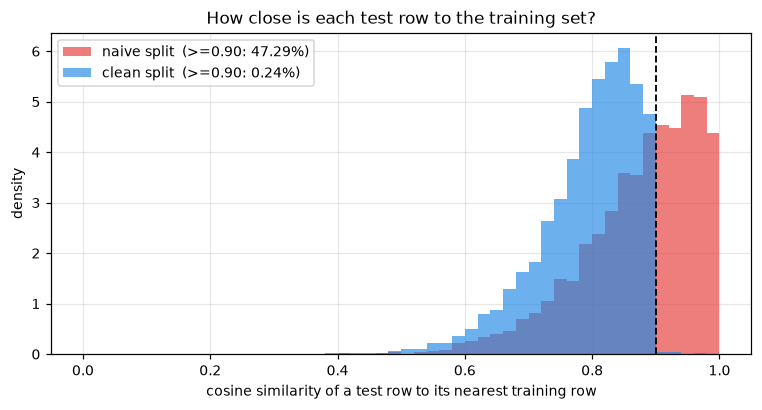

In [30]:
# Figure 4 - the strongest figure: test<->train similarity, naive vs clean
fig, ax = plt.subplots(figsize=(7, 3.8))
bins = np.linspace(0, 1, 51)
ax.hist(sim_naive, bins=bins, alpha=0.65, color="#e53935", density=True,
        label=f"naive split  (>=0.90: {leak_naive['ge_0.90_pct']}%)")
ax.hist(sim_clean, bins=bins, alpha=0.65, color="#1e88e5", density=True,
        label=f"clean split  (>=0.90: {leak_clean['ge_0.90_pct']}%)")
ax.axvline(0.90, color="black", ls="--", lw=1.2)
ax.set_xlabel("cosine similarity of a test row to its nearest training row")
ax.set_ylabel("density"); ax.set_title("How close is each test row to the training set?")
ax.legend(loc="upper left"); fig.tight_layout()
fig.savefig(FIGDIR / "04_leakage_similarity.png", bbox_inches="tight"); plt.show()

## 1.8 - Pre-registered prediction (written before anything is trained)

Recorded now, on purpose, so that stage 5 compares the confusion pairs against a prediction made **before** seeing any result. A prediction that holds is the most convincing paragraph in the analysis chapter; one that is refuted is more interesting still.

Expected confusion pairs:

- `get_invoice` <-> `check_invoice` (one verb apart)
- `get_refund` <-> `track_refund` <-> `check_refund_policy`
- `cancel_order` <-> `change_order` <-> `check_cancellation_fee`
- `contact_customer_service` <-> `contact_human_agent` (the most delicate pair in the file)
- `change_shipping_address` <-> `set_up_shipping_address`
- `complaint` <-> `payment_issue`

Expected robustness ranking from the flag slices: `Z` (typos) and `K` (keyword-only) hardest; `P` (politeness) no measurable effect.

## Summary of the day

Everything below is measured, not assumed. Nothing here required a GPU.

In [31]:
summary = [
    f"DATA             raw {len(df_raw):,} rows / 27 intents / 11 categories  (verified)",
    f"CLEANING         -> {len(df_dedup):,} after exact duplicates ({len(df_ws)-len(df_dedup):,} removed)",
    f"                 -> {len(reps_random):,} after family clustering at {D.NEAR_DUP_THRESHOLD}",
    f"                    ({n_groups:,} families, mean size {len(df_dedup)/n_groups:.2f})",
    f"LABEL CONFLICTS  {len(conflicts)} exact -> no measurable labelling ceiling from ambiguity",
    f"LEAKAGE naive    {leak_before['exact_pct']}% verbatim | {leak_before['ge_0.95_pct']}% >=0.95 | {leak_before['ge_0.90_pct']}% >=0.90",
    f"LEAKAGE clean    {leak_clean['exact_pct']}% verbatim | {leak_clean['ge_0.95_pct']}% >=0.95 | {leak_clean['ge_0.90_pct']}% >=0.90",
    f"SPLIT            clean {len(clean_tr)}/{len(clean_va)}/{len(clean_te)}   naive {len(naive_tr)}/{len(naive_va)}/{len(naive_te)}",
    f"                 seed {D.SPLIT_SEED}, stratified on intent, all 27 present in all six files",
    f"MAX_LENGTH       p99 = {p99} tokens -> max_length = {max_length}",
    "ARTIFACTS        labels.json, intent2cat.json, urgency_prior.json (all asserts passed)",
    "FIGURES          4 PNG files in results/figures/",
]
print("\n".join(summary))

DATA             raw 26,872 rows / 27 intents / 11 categories  (verified)
CLEANING         -> 24,554 after exact duplicates (2,318 removed)
                 -> 14,133 after family clustering at 0.9
                    (14,133 families, mean size 1.74)
LABEL CONFLICTS  0 exact -> no measurable labelling ceiling from ambiguity
LEAKAGE naive    10.49% verbatim | 30.64% >=0.95 | 52.02% >=0.90
LEAKAGE clean    0.0% verbatim | 0.05% >=0.95 | 0.24% >=0.90
SPLIT            clean 9893/2120/2120   naive 17187/3683/3684
                 seed 42, stratified on intent, all 27 present in all six files
MAX_LENGTH       p99 = 19 tokens -> max_length = 32
ARTIFACTS        labels.json, intent2cat.json, urgency_prior.json (all asserts passed)
FIGURES          4 PNG files in results/figures/
